# Model evaluation

In this notebook, I will compare the accuracy metrics of models

In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("..")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
import scienceplots  # noqa # pylint: disable=unused-import

plt.style.use(["science", "ieee", "default"])
plt.rcParams.update({"axes.grid": True})

In [4]:
from tqdm.auto import tqdm

## Prepare dataloader

In [5]:
from pathlib import Path

ROOT_DATA_DIR = Path("../data/")

In [6]:
from collections import defaultdict

import lightning.pytorch as pl
import torch
from lightning.pytorch import Trainer, seed_everything
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from torch import Tensor, nn
from torch.utils.data import DataLoader, TensorDataset
from lightning.pytorch.callbacks import LearningRateFinder

from src.utils import get_metrics

take only 1 dataset, 1 concrete time series for now...

In [7]:
DATA_DIR = ROOT_DATA_DIR / "KPI-Anomaly-Detection/Preliminary_dataset"

In [8]:
df = pd.read_parquet(DATA_DIR / "train.parquet")
df = df[df["KPI ID"] == "02e99bd4f6cfb33f"].copy()
df = df[df.index > 1.49 * 1e9].copy()
df = df.query("timestamp < 1496538120").copy()
df["time"] = df.index - df.index[0]
# df["value"] = df["value"].diff()
# df = df.query('stock==1 & day==0 & train==1')
# df.value = df.value.pct_change()
df.dropna(inplace=True)

In [9]:
def convert_to_windows(x, window_size):
    # convert input time series x to
    # time series of lags, first window_size observations are dropped
    windows = []
    for i in range(window_size, len(x)):
        w = x[i - window_size : i]
        windows.append(w)
    windows = np.array(windows)
    return windows

In [10]:
df["value_diff"] = df["value"].diff()
tr_cols = ["value", "value_diff"]
df = df.dropna()

In [11]:
# fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# plt.subplot(1, 2, 1)
# plt.plot(df.value.diff())
# plt.subplot(1, 2, 2)
# plt.hist(df.value)
# plt.yscale("log")
# plt.tight_layout();

In [12]:
window_size = 8
train_proportion = 0.9
batch_size = 16
learning_rate = 1e-5
epochs = 30

In [13]:
x = df[tr_cols].values.copy()
scaler = MinMaxScaler()
x = scaler.fit_transform(x)
# x_scaled = x
x = convert_to_windows(x, window_size)
y = df["target"].values
y = y[window_size:]

# class_weights = compute_class_weight('balanced', classes=[0, 1], y=y.ravel())
# class_weights = class_weights / class_weights.sum()

x = torch.Tensor(x).float()
y = torch.Tensor(y).float()

train_idx = int(len(x) * train_proportion)
# train_idx = int(1.495 * 1e9)

tr, va = x[:train_idx], x[train_idx:]
# x = np.hstack([x, y.reshape(-1, 1)])
# y = y.reshape(-1, 1)
ytr, yva = y[:train_idx], y[train_idx:]
tr_dataset = TensorDataset(tr, ytr)
va_dataset = TensorDataset(va, yva)

In [14]:
# fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# plt.sca(axs[0])
# plt.plot(tr[:, 0, 0])
# plt.sca(axs[1])
# plt.plot(tr[:, 0, 1])
# fig.tight_layout();

## Evaluate models on 1 dataset

In [15]:
from src.utils import MetricTracker

In [16]:
from src.transformer import TransformerAnomalyDetector

### Scaled Dot-Product

In [17]:
window_size = 8
train_proportion = 0.9
batch_size = 2 * 4096
epochs = 100

In [18]:
seed_everything(1)

tr_dl = DataLoader(tr_dataset, batch_size=batch_size, shuffle=False)
va_dl = DataLoader(va_dataset, batch_size=batch_size, shuffle=False)

Global seed set to 1


In [19]:
len(tr_dl), len(va_dl), tr_cols

(6, 1, ['value', 'value_diff'])

In [20]:
seed_everything(1)

input_dim = len(tr_cols)

block_args = {
    "input_dim": 8,
    "num_heads": 2,
    "dim_feedforward": 2 * 8,
    "num_layers": 1,
    "enable_layer_norm": False,
}
positional_encoder_args = {
    "enable": False,
    "max_len": window_size,
}

loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(5))

model_params = {
    "input_dim": input_dim,
    "block_input_dim": block_args["input_dim"],
    "block_args": block_args,
    "num_layers": block_args["num_layers"],
    "positional_encoder_args": positional_encoder_args,
    "learning_rate": 1e-1,
    "dropout": 0.0,
    "loss_fn": loss_fn,
}


model = TransformerAnomalyDetector(
    **model_params,
)

Global seed set to 1
positional encoding disabled
layer norm disabled


In [21]:
seed_everything(1)
trainer = pl.Trainer(
    accelerator='cpu',
    max_epochs=epochs,
    log_every_n_steps=1,
    callbacks=[LearningRateFinder(), MetricTracker()],
)

trainer.fit(model, tr_dl, va_dl)

Global seed set to 1


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/cym/prj2/finn/notebooks/icl_thesis-master/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/home/cym/prj2/finn/notebooks/icl_thesis-master/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

LR finder stopped early after 99 steps due to diverging loss.
Learning rate set to 7.585775750291837e-08
Restoring states from the checkpoint path at /home/cym/prj2/finn/notebooks/icl_thesis-master/notebooks/.lr_find_9ce884b6-d141-42a0-a8ce-5c00b9da1bfe.ckpt
Restored all states from the checkpoint at /home/cym/prj2/finn/notebooks/icl_thesis-master/notebooks/.lr_find_9ce884b6-d141-42a0-a8ce-5c00b9da1bfe.ckpt

  | Name                | Type               | Params
-----------------------------------------------------------
0 | front_linear        | Linear             | 24    
1 | positional_encoder  | Identity           | 0     
2 | transformer_encoder | TransformerEncoder | 544   
3 | final_linear        | Linear             | 9     
4 | loss_fn             | BCEWithLogitsLoss  | 0     
-----------------------------------------------------------
577       Trainable params
0         Non-trainable params
577       Total params
0.002     Total estimated model params size (MB)
Restored all s

Sanity Checking: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


In [22]:
# %reload_ext tensorboard
# %tensorboard --logdir=lightning_logs/

In [23]:
mt = trainer.callbacks[1]

In [24]:
from copy import deepcopy

res = deepcopy(mt.collection)
for r in res:
    for k, v in r.items():
        if type(v) == torch.Tensor:
            r[k] = np.float32(v.cpu())
        else:
            r[k] = np.float32(v)
res = pd.DataFrame(res)

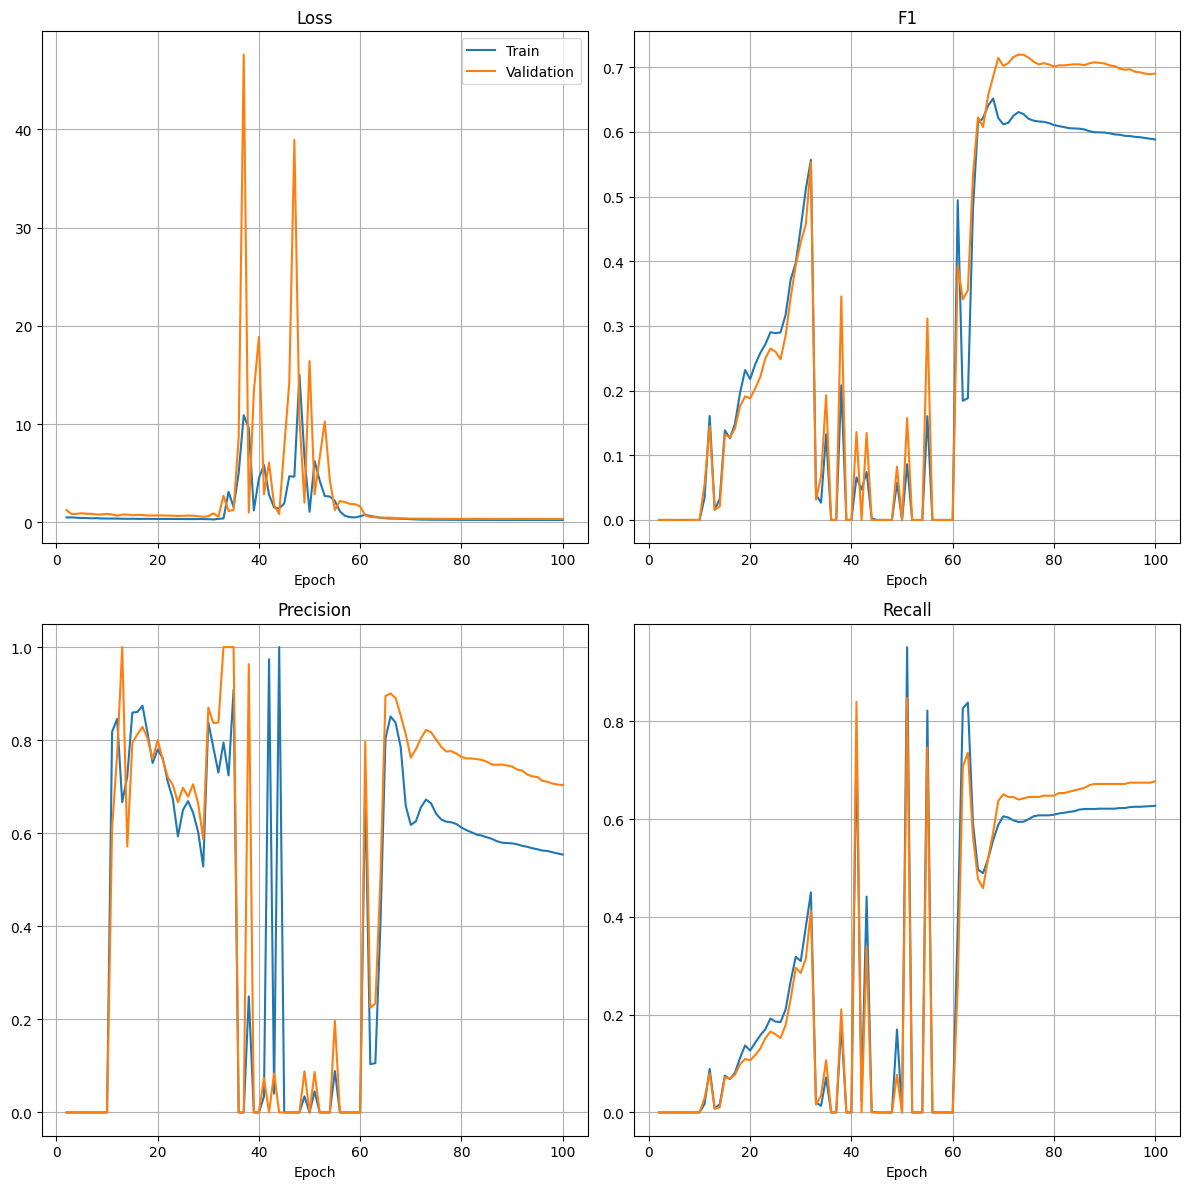

In [25]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

plt.sca(axs[0, 0])
plt.plot(res["train_loss"], label="Train")
plt.plot(res["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.sca(axs[0, 1])
plt.plot(res["train_f1"], label="Train")
plt.plot(res["val_f1"], label="Validation")
plt.title("F1")
plt.xlabel("Epoch")
# plt.legend()
plt.sca(axs[1, 0])
plt.plot(res["train_precision"], label="Train")
plt.plot(res["val_precision"], label="Validation")
plt.title("Precision")
plt.xlabel("Epoch")
# plt.legend()
plt.sca(axs[1, 1])
plt.plot(res["train_recall"], label="Train")
plt.plot(res["val_recall"], label="Validation")
plt.title("Recall")
plt.xlabel("Epoch")
# plt.legend()
fig.tight_layout()
plt.savefig('../tex/Figures/etc/gradient_explosion.pdf');

### Linear regression

In [26]:
from src.transformer import LinearRegressionAnomalyDetector

In [27]:
window_size = 8
train_proportion = 0.9
batch_size = 2 * 4096
epochs = 260

In [28]:
seed_everything(1)

tr_dl = DataLoader(tr_dataset, batch_size=batch_size, shuffle=False)
va_dl = DataLoader(va_dataset, batch_size=batch_size, shuffle=False)

Global seed set to 1


In [29]:
seed_everything(1)

input_dim = len(tr_cols) * window_size

loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(5))
# loss_fn = nn.BCEWithLogitsLoss()

model_params = {
    "input_dim": input_dim,
    "learning_rate": 1e-5,
    "loss_fn": loss_fn,
}

model = LinearRegressionAnomalyDetector(
    **model_params,
)

Global seed set to 1


In [30]:
seed_everything(1)
trainer = pl.Trainer(
    accelerator='cpu',
    max_epochs=epochs,
    log_every_n_steps=1,
    callbacks=[LearningRateFinder(), MetricTracker()],
)

trainer.fit(model, tr_dl, va_dl)

Global seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/cym/prj2/finn/notebooks/icl_thesis-master/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/home/cym/prj2/finn/notebooks/icl_thesis-master/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Learning rate set to 0.13182567385564073
Restoring states from the checkpoint path at /home/cym/prj2/finn/notebooks/icl_thesis-master/notebooks/.lr_find_7e09d360-4317-48d7-bdd0-e6879c16ddc9.ckpt
Restored all states from the checkpoint at /home/cym/prj2/finn/notebooks/icl_thesis-master/notebooks/.lr_find_7e09d360-4317-48d7-bdd0-e6879c16ddc9.ckpt

  | Name    | Type              | Params
----------------------------------------------
0 | linear  | Linear            | 17    
1 | loss_fn | BCEWithLogitsLoss | 0     
----------------------------------------------
17        Trainable params
0         Non-trainable params
17        Total params
0.000     Total estimated model params size (MB)
Restored all states from the checkpoint at /home/cym/prj2/finn/notebooks/icl_thesis-master/notebooks/.lr_find_7e09d360-4317-48d7-bdd0-e6879c16ddc9.ckpt


Sanity Checking: 0it [00:00, ?it/s]

/home/cym/prj2/finn/notebooks/icl_thesis-master/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=260` reached.


In [31]:
mt = trainer.callbacks[1]

In [32]:
from copy import deepcopy

res = deepcopy(mt.collection)
for r in res:
    for k, v in r.items():
        if type(v) == torch.Tensor:
            r[k] = np.float32(v.cpu())
        else:
            r[k] = np.float32(v)
res = pd.DataFrame(res)

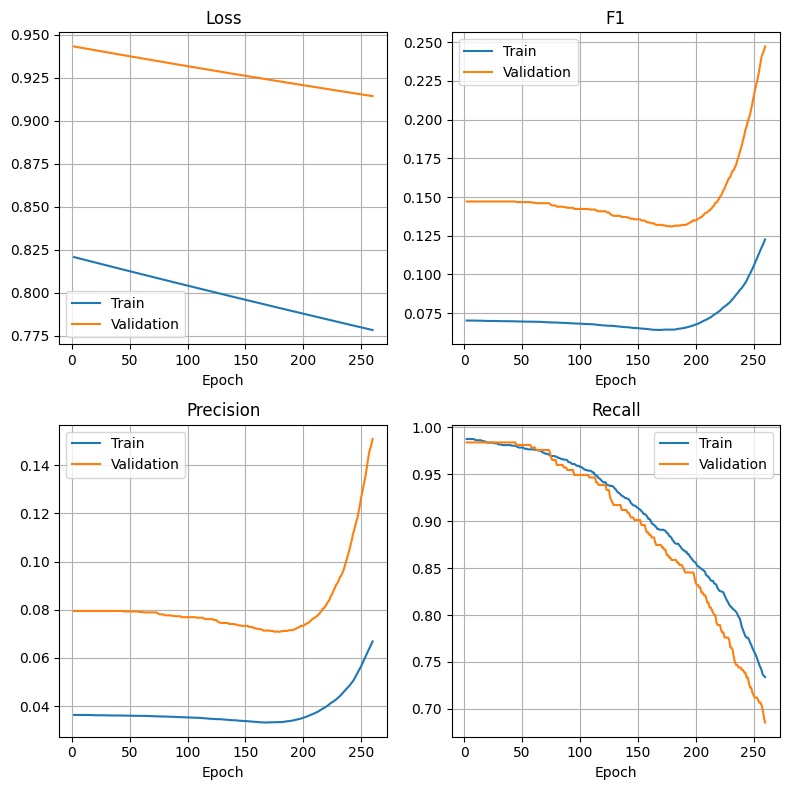

In [33]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))

plt.sca(axs[0, 0])
plt.plot(res["train_loss"], label="Train")
plt.plot(res["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.sca(axs[0, 1])
plt.plot(res["train_f1"], label="Train")
plt.plot(res["val_f1"], label="Validation")
plt.title("F1")
plt.xlabel("Epoch")
plt.legend()
plt.sca(axs[1, 0])
plt.plot(res["train_precision"], label="Train")
plt.plot(res["val_precision"], label="Validation")
plt.title("Precision")
plt.xlabel("Epoch")
plt.legend()
plt.sca(axs[1, 1])
plt.plot(res["train_recall"], label="Train")
plt.plot(res["val_recall"], label="Validation")
plt.title("Recall")
plt.xlabel("Epoch")
plt.legend()
fig.tight_layout();

slightly worse, but works :)

### Linear attention

In [34]:
from src.transformer import LinearTransformerAnomalyDetector
from src.utils import GradNormCallback

In [35]:
window_size = 8
train_proportion = 0.9
batch_size = 2 * 4096
epochs = 150

In [36]:
seed_everything(1)

tr_dl = DataLoader(tr_dataset, batch_size=batch_size, shuffle=False)
va_dl = DataLoader(va_dataset, batch_size=batch_size, shuffle=False)

Global seed set to 1


In [37]:
seed_everything(1)

input_dim = len(tr_cols)

block_args = {
    "input_dim": 8,
    "dim_feedforward": 2 * 8,
    "num_layers": 1,
    "enable_layer_norm": False,
}
positional_encoder_args = {
    "enable": False,
    "max_len": window_size,
}

loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(5))

model_params = {
    "input_dim": input_dim,
    "block_input_dim": block_args["input_dim"],
    "block_args": block_args,
    "num_layers": block_args["num_layers"],
    "positional_encoder_args": positional_encoder_args,
    "learning_rate": 1e-1,
    "dropout": 0.0,
    "loss_fn": loss_fn,
}

model = LinearTransformerAnomalyDetector(
    **model_params,
)

Global seed set to 1
layer norm disabled
positional encoding disabled


In [38]:
seed_everything(1)
trainer = pl.Trainer(
    accelerator='cpu',
    max_epochs=epochs,
    log_every_n_steps=1,
    callbacks=[LearningRateFinder(max_lr=1e-2), MetricTracker(), GradNormCallback()],
    gradient_clip_val=1.2,
)

trainer.fit(model, tr_dl, va_dl)

Global seed set to 1


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/cym/prj2/finn/notebooks/icl_thesis-master/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/home/cym/prj2/finn/notebooks/icl_thesis-master/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Learning rate set to 0.005754399373371567
Restoring states from the checkpoint path at /home/cym/prj2/finn/notebooks/icl_thesis-master/notebooks/.lr_find_bf60ddbb-f187-4b2c-9b54-4f15e6cebe97.ckpt
Restored all states from the checkpoint at /home/cym/prj2/finn/notebooks/icl_thesis-master/notebooks/.lr_find_bf60ddbb-f187-4b2c-9b54-4f15e6cebe97.ckpt

  | Name                | Type                     | Params
-----------------------------------------------------------------
0 | front_linear        | Linear                   | 24    
1 | transformer_encoder | LinearTransformerEncoder | 544   
2 | positional_encoder  | Identity                 | 0     
3 | final_linear        | Linear                   | 9     
4 | loss_fn             | BCEWithLogitsLoss        | 0     
-----------------------------------------------------------------
577       Trainable params
0         Non-trainable params
577       Total params
0.002     Total estimated mode

Sanity Checking: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=150` reached.


In [39]:
mt = trainer.callbacks[1]

In [40]:
from copy import deepcopy

res = deepcopy(mt.collection)
for r in res:
    for k, v in r.items():
        if type(v) == torch.Tensor:
            r[k] = np.float32(v.cpu())
        else:
            r[k] = np.float32(v)
res = pd.DataFrame(res)

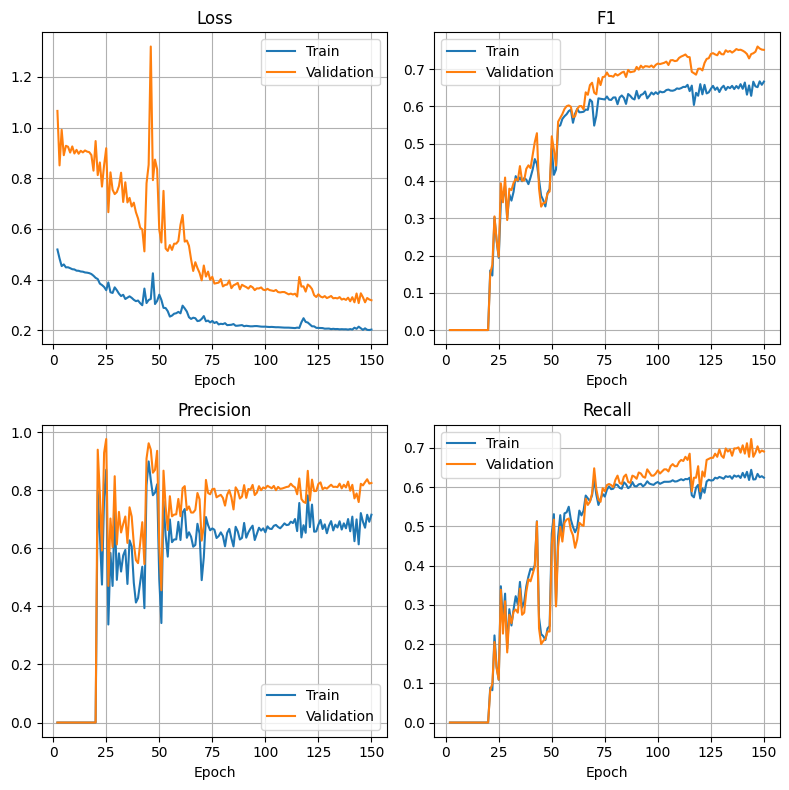

In [41]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))

plt.sca(axs[0, 0])
plt.plot(res["train_loss"], label="Train")
plt.plot(res["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.sca(axs[0, 1])
plt.plot(res["train_f1"], label="Train")
plt.plot(res["val_f1"], label="Validation")
plt.title("F1")
plt.xlabel("Epoch")
plt.legend()
plt.sca(axs[1, 0])
plt.plot(res["train_precision"], label="Train")
plt.plot(res["val_precision"], label="Validation")
plt.title("Precision")
plt.xlabel("Epoch")
plt.legend()
plt.sca(axs[1, 1])
plt.plot(res["train_recall"], label="Train")
plt.plot(res["val_recall"], label="Validation")
plt.title("Recall")
plt.xlabel("Epoch")
plt.legend()
fig.tight_layout();

## Evaluate on all datasets

In [42]:
from pathlib import Path

ROOT_DATA_DIR = Path("../data/")

In [43]:
from src.utils import (
    get_metrics_from_tracker,
    plot_metrics_from_tracker,
    prepare_dataset_for_evaluation,
)

In [44]:
from lightning.pytorch.callbacks import LearningRateFinder

from src.utils import MetricTracker
from src.transformer import TransformerAnomalyDetector
from src.transformer import LinearRegressionAnomalyDetector
from src.utils import GradNormCallback

In [45]:
window_size = 8
train_proportion = 0.9
batch_size = 2 * 4096
epochs = 150

In [46]:
model_to_epochs = {
    'Transformer': 100,
    'LR': 260,
    'LinearTransformer': 150,
}

In [47]:
dataset_name = "KPI"
tr_dl, va_dl, tr_cols = prepare_dataset_for_evaluation(
    dataset_name=dataset_name,
    window_size=8,
    train_proportion=0.9,
    batch_size=batch_size,
    root_data_dir=ROOT_DATA_DIR,
)

# dataset_name = "FI2010"
# tr_dl, va_dl, tr_cols = prepare_dataset_for_evaluation(
#     dataset_name=dataset_name,
#     window_size=8,
#     train_proportion=0.9,
#     batch_size=batch_size,
#     root_data_dir=ROOT_DATA_DIR,
# )

# dataset_name = "NAB"
# tr_dl, va_dl, tr_cols = prepare_dataset_for_evaluation(
#     dataset_name=dataset_name,
#     window_size=8,
#     train_proportion=0.9,
#     batch_size=batch_size,
#     root_data_dir=ROOT_DATA_DIR,
# )

Global seed set to 1
y_tr mean 0.036821845918893814, y_va mean 0.08067986369132996
Global seed set to 1


In [48]:
seed_everything(1)

input_dim = len(tr_cols)

block_args = {
    "input_dim": 8,
    "num_heads": 2,
    "dim_feedforward": 2 * 8,
    "num_layers": 1,
    "enable_layer_norm": False,
}
positional_encoder_args = {
    "enable": False,
    "max_len": window_size,
}

loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(5))
# loss_fn = nn.BCEWithLogitsLoss()

model_params = {
    "input_dim": input_dim,
    "block_input_dim": block_args["input_dim"],
    "block_args": block_args,
    "num_layers": block_args["num_layers"],
    "positional_encoder_args": positional_encoder_args,
    "learning_rate": 1e-1,
    "dropout": 0.0,
    "loss_fn": loss_fn,
}


model = TransformerAnomalyDetector(
    **model_params,
)

Global seed set to 1
positional encoding disabled
layer norm disabled


In [49]:
seed_everything(1)
trainer = pl.Trainer(
    accelerator='cpu',
    max_epochs=epochs,
    log_every_n_steps=1,
    callbacks=[LearningRateFinder(), MetricTracker(), GradNormCallback()],
    # gradient_clip_val=0.01,
)

trainer.fit(model, tr_dl, va_dl)

Global seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/cym/prj2/finn/notebooks/icl_thesis-master/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/home/cym/prj2/finn/notebooks/icl_thesis-master/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

LR finder stopped early after 99 steps due to diverging loss.
Learning rate set to 7.585775750291837e-08
Restoring states from the checkpoint path at /home/cym/prj2/finn/notebooks/icl_thesis-master/notebooks/.lr_find_ee22112b-4d61-40ec-ba96-9bb6186fb78f.ckpt
Restored all states from the checkpoint at /home/cym/prj2/finn/notebooks/icl_thesis-master/notebooks/.lr_find_ee22112b-4d61-40ec-ba96-9bb6186fb78f.ckpt

  | Name                | Type               | Params
-----------------------------------------------------------
0 | front_linear        | Linear             | 24    
1 | positional_encoder  | Identity           | 0     
2 | transformer_encoder | TransformerEncoder | 544   
3 | final_linear        | Linear             | 9     
4 | loss_fn             | BCEWithLogitsLoss  | 0     
-----------------------------------------------------------
577       Trainable params
0         Non-trainable params
577       Total params
0.002     Total estimated model params size (MB)
Restored all s

Sanity Checking: 0it [00:00, ?it/s]

/home/cym/prj2/finn/notebooks/icl_thesis-master/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=150` reached.


In [50]:
mt = trainer.callbacks[1]

In [51]:
res = get_metrics_from_tracker(mt)

In [52]:
res.describe()

,my_model/grad_norm,val_loss,val_accuracy,val_precision,val_recall,val_auc,val_f1,train_loss,train_accuracy,train_precision,train_recall,train_auc,train_f1
count,150.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000
mean,16.444558,1.925308,0.924868,0.571120,0.444617,0.705816,0.454916,0.933765,0.948531,0.484624,0.422880,0.695753,0.395951
std,38.884384,5.678998,0.092825,0.311843,0.301235,0.145545,0.297280,2.003921,0.097070,0.272460,0.279426,0.133553,0.255286
min,0.000000,0.341159,0.138554,0.000000,0.000000,0.458498,0.000000,0.235585,0.206633,0.000000,0.000000,0.472614,0.000000
25%,1.081200,0.342119,0.919966,0.587302,0.080000,0.533965,0.135952,0.241970,0.963489,0.542411,0.088961,0.535578,0.126354
50%,9.341315,0.362648,0.949871,0.695652,0.653333,0.815575,0.688259,0.262959,0.966932,0.549631,0.611688,0.796108,0.584034
75%,12.285650,0.803823,0.950732,0.753799,0.685333,0.828228,0.691689,0.413113,0.968056,0.623584,0.629221,0.804668,0.589493
max,325.668427,47.612705,0.959768,1.000000,0.848000,0.832345,0.719640,15.026065,0.978576,1.000000,0.951948,0.805793,0.651728


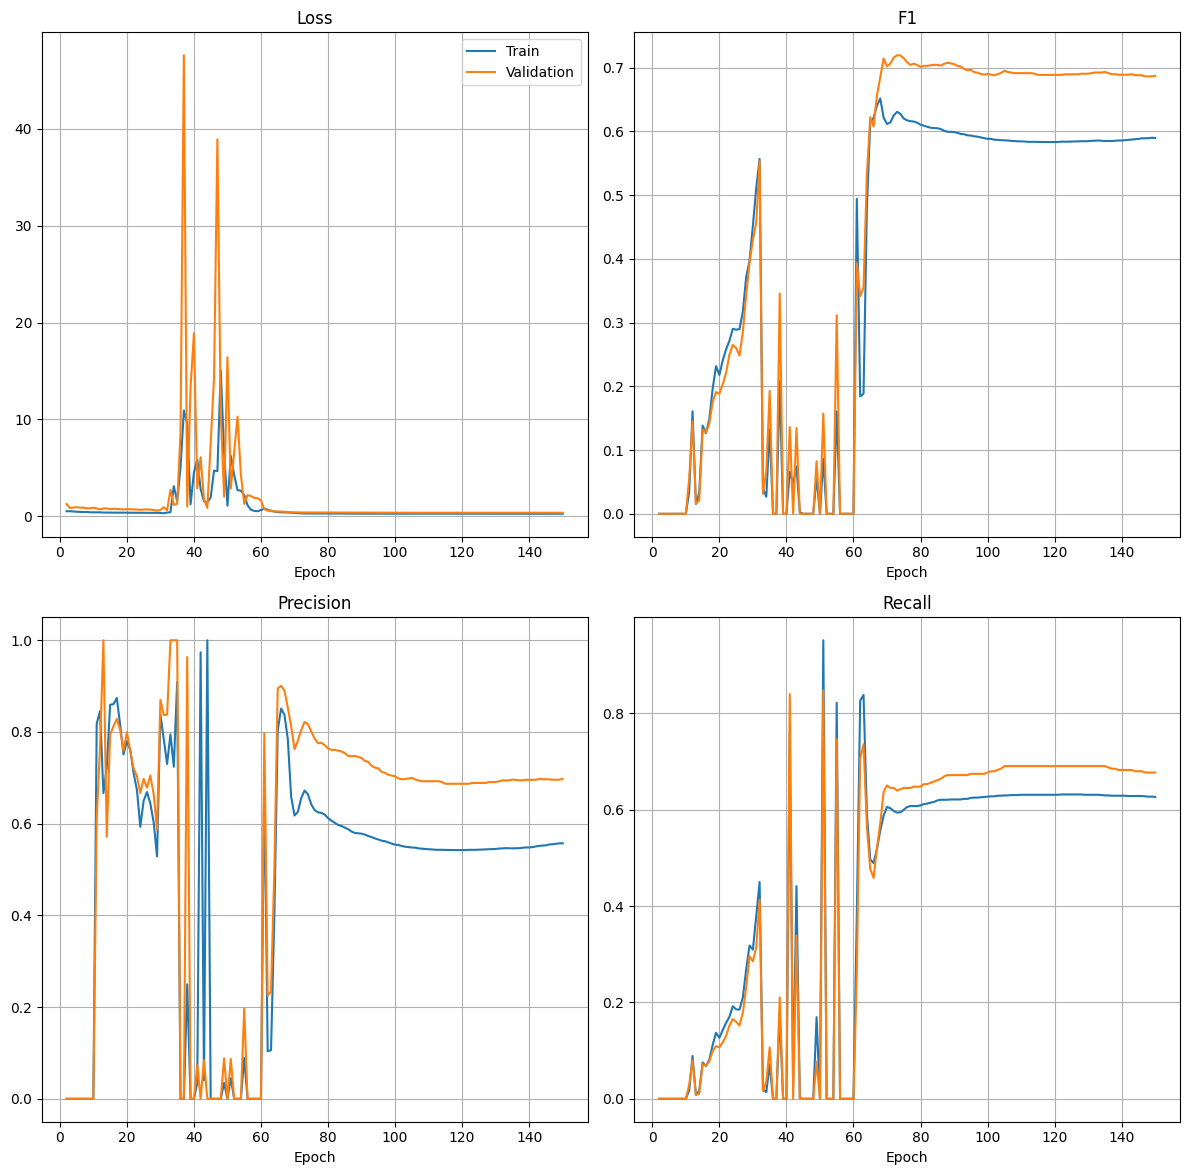

In [53]:
plot_metrics_from_tracker(res, dataset_name='', filename='../tex/Figures/gradient_explosion.png')
plt.show()

## OLD: export model weights

In [54]:
# Print model's state_dict
print("Model's state_dict:")
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor].size())

Model's state_dict:
front_linear.weight 	 torch.Size([8, 2])
front_linear.bias 	 torch.Size([8])
transformer_encoder.layers.0.self_attn.query_mat.weight 	 torch.Size([8, 8])
transformer_encoder.layers.0.self_attn.key_mat.weight 	 torch.Size([8, 8])
transformer_encoder.layers.0.self_attn.value_mat.weight 	 torch.Size([8, 8])
transformer_encoder.layers.0.self_attn.o_proj.weight 	 torch.Size([8, 8])
transformer_encoder.layers.0.self_attn.o_proj.bias 	 torch.Size([8])
transformer_encoder.layers.0.linear_net.0.weight 	 torch.Size([16, 8])
transformer_encoder.layers.0.linear_net.0.bias 	 torch.Size([16])
transformer_encoder.layers.0.linear_net.3.weight 	 torch.Size([8, 16])
transformer_encoder.layers.0.linear_net.3.bias 	 torch.Size([8])
final_linear.weight 	 torch.Size([1, 8])
final_linear.bias 	 torch.Size([1])
loss_fn.pos_weight 	 torch.Size([])


https://stackoverflow.com/questions/2117313/initializing-constant-static-array-in-header-file

In [55]:
# template_params = 'const static char %s[];'
# with open('../vitis_hls/transformer/scaled_dp_params.h', 'w') as f:
#     for name, param in model.named_parameters():
#         n = name.upper()
#         # s = n.split('.')
#         n = n.replace('.', '_')
#         # p = [f'{x:.6f}' for x in param.ravel().detach().numpy()]
#         # p = ', '.join(p)
#         print(template_params % (n), file=f)

In [56]:
template_params = 'inline constexpr static double %s[%s] = {%s};'
with open('../vitis_hls/transformer/scaled_dp_params.h', 'w') as f:
    for name, param in model.named_parameters():
        n = name.upper()
        # s = param.size()
        n = n.replace('.', '_')
        p = [f'{x:.6f}' for x in param.ravel().detach().numpy()]
        l = len(p)
        p = ', '.join(p)
        print(template_params % (n, l, p), file=f)

In [57]:
xx = torch.tensor([[
    [-1, -1],
    [-1, 0],
    [-1, 1],
    [0, -1],
    [0, 0],
    [0, 1],
    [1, -1],
    [1, 1],
]]).float()
model(xx)

tensor([-30.0401], grad_fn=<SelectBackward0>)

In [58]:
xx.shape

torch.Size([1, 8, 2])

In [59]:
x.shape

torch.Size([46471, 8, 2])

In [60]:
model.front_linear.bias

Parameter containing:
tensor([-0.8720, -0.5788, -0.4923,  2.0634, -0.2339, -1.2757,  0.2674, -0.8135],
       requires_grad=True)

In [61]:
model.front_linear.state_dict()['weight'].shape

torch.Size([8, 2])

In [62]:
yy = model.front_linear(xx)
print(yy)

tensor([[[-3.6765e+00,  2.3998e+00, -1.5060e+00,  1.3447e+00, -3.3175e-01,
          -1.5162e+00, -1.4903e+00, -1.2552e+00],
         [-3.7362e+00,  2.8546e+00, -1.5716e+00,  1.0795e+00, -9.7524e-02,
          -7.6087e-01, -1.5714e+00, -1.6039e+00],
         [-3.7958e+00,  3.3094e+00, -1.6372e+00,  8.1421e-01,  1.3671e-01,
          -5.5758e-03, -1.6526e+00, -1.9526e+00],
         [-8.1237e-01, -1.0336e+00, -4.2666e-01,  2.3287e+00, -4.6812e-01,
          -2.0310e+00,  3.4851e-01, -4.6480e-01],
         [-8.7204e-01, -5.7879e-01, -4.9227e-01,  2.0634e+00, -2.3389e-01,
          -1.2757e+00,  2.6739e-01, -8.1351e-01],
         [-9.3172e-01, -1.2401e-01, -5.5787e-01,  1.7982e+00,  3.3864e-04,
          -5.2040e-01,  1.8627e-01, -1.1622e+00],
         [ 2.0518e+00, -4.4669e+00,  6.5267e-01,  3.3127e+00, -6.0449e-01,
          -2.5458e+00,  2.1873e+00,  3.2557e-01],
         [ 1.9324e+00, -3.5574e+00,  5.2146e-01,  2.7822e+00, -1.3603e-01,
          -1.0352e+00,  2.0251e+00, -3.7184e-01]]]

done

In [64]:
#qkv = model.transformer_encoder.layers[0].self_attn.qkv_proj(yy)
#print(qkv.shape, qkv)

In [65]:
attn = model.transformer_encoder.layers[0].self_attn

q_raw = attn.query_mat(yy)
k_raw = attn.key_mat(yy)
v_raw = attn.value_mat(yy)

qkv = torch.cat([q_raw, k_raw, v_raw], dim=-1)
print(qkv.shape, qkv)

torch.Size([1, 8, 24]) tensor([[[-1.6119e+01, -2.4659e+01,  1.6526e+01, -2.1904e+01,  1.3512e+01,
          -4.8930e+00,  1.5553e+01, -1.8769e+00,  4.4611e+01,  2.2131e+01,
          -3.4822e+01,  4.1573e+01, -6.1764e+00,  6.5776e+00, -9.1618e+00,
           1.4048e+00, -2.4038e+00,  1.1335e+01, -5.7948e+00, -7.6042e+00,
           1.9636e+00, -9.6800e+00, -4.3403e+00,  5.9485e+00],
         [-1.8278e+01, -2.6099e+01,  1.7826e+01, -2.3616e+01,  1.2903e+01,
          -3.8144e+00,  1.4249e+01, -3.7017e+00,  5.4010e+01,  2.4348e+01,
          -4.2756e+01,  4.4566e+01, -1.9889e+01, -6.6096e+00, -1.8950e+01,
           1.1657e+01, -5.4251e-01,  1.4564e+01, -6.3037e+00, -5.6304e+00,
           1.8524e+00, -7.8563e+00, -5.5743e+00,  6.9891e+00],
         [-2.0436e+01, -2.7540e+01,  1.9126e+01, -2.5328e+01,  1.2294e+01,
          -2.7357e+00,  1.2945e+01, -5.5265e+00,  6.3409e+01,  2.6564e+01,
          -5.0689e+01,  4.7558e+01, -3.3602e+01, -1.9797e+01, -2.8737e+01,
           2.1909e+01,  1.

done

In [66]:
qkv.shape

torch.Size([1, 8, 24])

In [68]:
batch_size = yy.shape[0]
seq_length = yy.shape[1]
num_heads = attn.num_heads
head_dim = attn.head_dim

q = q_raw.reshape(batch_size, seq_length, num_heads, head_dim).permute(0, 2, 1, 3)
k = k_raw.reshape(batch_size, seq_length, num_heads, head_dim).permute(0, 2, 1, 3)
v = v_raw.reshape(batch_size, seq_length, num_heads, head_dim).permute(0, 2, 1, 3)

print(q, k, v)

tensor([[[[-16.1191, -24.6588,  16.5257, -21.9040],
          [-18.2776, -26.0994,  17.8259, -23.6158],
          [-20.4362, -27.5400,  19.1261, -25.3276],
          [ 14.0620,  11.6055, -10.5286,  12.5492],
          [ 11.9035,  10.1649,  -9.2283,  10.8374],
          [  9.7449,   8.7243,  -7.9281,   9.1256],
          [ 44.2432,  47.8698, -37.5828,  47.0024],
          [ 39.9261,  44.9886, -34.9823,  43.5788]],

         [[ 13.5120,  -4.8930,  15.5531,  -1.8769],
          [ 12.9028,  -3.8144,  14.2488,  -3.7017],
          [ 12.2937,  -2.7357,  12.9446,  -5.5265],
          [ 10.9090,   3.6077,  10.1079,  -2.7744],
          [ 10.2998,   4.6863,   8.8036,  -4.5992],
          [  9.6906,   5.7650,   7.4994,  -6.4240],
          [  8.3059,  12.1084,   4.6627,  -3.6718],
          [  7.0876,  14.2657,   2.0542,  -7.3214]]]],
       grad_fn=<PermuteBackward0>) tensor([[[[ 44.6108,  22.1313, -34.8223,  41.5735],
          [ 54.0100,  24.3477, -42.7558,  44.5658],
          [ 63.4092,  26

In [67]:
#batch_size = 1
#seq_length = 8
#qkv = qkv.reshape(batch_size, seq_length, 2, 3 * 4)
# print(qkv)
#qkv = qkv.permute(0, 2, 1, 3)
#print(qkv)
#q, k, v = qkv.chunk(3, dim=-1)

In [69]:
q.shape

torch.Size([1, 2, 8, 4])

In [70]:
q

tensor([[[[-16.1191, -24.6588,  16.5257, -21.9040],
          [-18.2776, -26.0994,  17.8259, -23.6158],
          [-20.4362, -27.5400,  19.1261, -25.3276],
          [ 14.0620,  11.6055, -10.5286,  12.5492],
          [ 11.9035,  10.1649,  -9.2283,  10.8374],
          [  9.7449,   8.7243,  -7.9281,   9.1256],
          [ 44.2432,  47.8698, -37.5828,  47.0024],
          [ 39.9261,  44.9886, -34.9823,  43.5788]],

         [[ 13.5120,  -4.8930,  15.5531,  -1.8769],
          [ 12.9028,  -3.8144,  14.2488,  -3.7017],
          [ 12.2937,  -2.7357,  12.9446,  -5.5265],
          [ 10.9090,   3.6077,  10.1079,  -2.7744],
          [ 10.2998,   4.6863,   8.8036,  -4.5992],
          [  9.6906,   5.7650,   7.4994,  -6.4240],
          [  8.3059,  12.1084,   4.6627,  -3.6718],
          [  7.0876,  14.2657,   2.0542,  -7.3214]]]],
       grad_fn=<PermuteBackward0>)

In [71]:
k

tensor([[[[ 44.6108,  22.1313, -34.8223,  41.5735],
          [ 54.0100,  24.3477, -42.7558,  44.5658],
          [ 63.4092,  26.5641, -50.6892,  47.5581],
          [-16.8546,  -2.7419,  17.6006,  -3.2868],
          [ -7.4554,  -0.5255,   9.6671,  -0.2945],
          [  1.9438,   1.6909,   1.7337,   2.6978],
          [-78.3201, -27.6150,  70.0235, -48.1470],
          [-59.5217, -23.1822,  54.1566, -42.1624]],

         [[ -6.1764,   6.5776,  -9.1618,   1.4048],
          [-19.8891,  -6.6096, -18.9496,  11.6571],
          [-33.6018, -19.7968, -28.7374,  21.9095],
          [ 41.0682,  41.1044,  31.0154, -31.7085],
          [ 27.3555,  27.9172,  21.2276, -21.4562],
          [ 13.6428,  14.7300,  11.4398, -11.2038],
          [ 88.3127,  75.6312,  71.1927, -64.8218],
          [ 60.8873,  49.2568,  51.6171, -44.3171]]]],
       grad_fn=<PermuteBackward0>)

In [72]:
v

tensor([[[[ -2.4038,  11.3346,  -5.7948,  -7.6042],
          [ -0.5425,  14.5640,  -6.3037,  -5.6304],
          [  1.3188,  17.7935,  -6.8127,  -3.6566],
          [ -8.0419,  -4.3305,  -1.6368,  -8.7183],
          [ -6.1806,  -1.1011,  -2.1458,  -6.7445],
          [ -4.3192,   2.1284,  -2.6548,  -4.7707],
          [-13.6799, -19.9956,   2.5211,  -9.8325],
          [ -9.9573, -13.5368,   1.5031,  -5.8849]],

         [[  1.9636,  -9.6800,  -4.3403,   5.9485],
          [  1.8524,  -7.8563,  -5.5743,   6.9891],
          [  1.7412,  -6.0325,  -6.8083,   8.0297],
          [  1.0650, -10.1969,   3.3335,  -0.1226],
          [  0.9538,  -8.3732,   2.0995,   0.9180],
          [  0.8426,  -6.5494,   0.8655,   1.9586],
          [  0.1664, -10.7138,  11.0074,  -6.1938],
          [ -0.0560,  -7.0663,   8.5394,  -4.1126]]]],
       grad_fn=<PermuteBackward0>)

done

In [73]:
import math
import torch.nn.functional as F
d_k = q.size()[-1]
attn_logits = torch.matmul(q, k.transpose(-2, -1))  # [Batch, Head, SeqLen, SeqLen]
attn_logits = attn_logits / math.sqrt(d_k)
attention = F.softmax(attn_logits, dim=-1)  # [Batch, Head, SeqLen, SeqLen]

In [74]:
attn_logits.shape

torch.Size([1, 2, 8, 8])

In [75]:
attn_logits

tensor([[[[-1375.4512, -1576.8557, -1778.2600,   351.0732,   149.6688,
             -51.7356,  2077.5977,  1674.7888],
          [-1497.7612, -1718.6252, -1939.4890,   385.4944,   164.6305,
             -56.2334,  2268.7500,  1827.0221],
          [-1620.0713, -1860.3948, -2100.7183,   419.9157,   179.5922,
             -60.7313,  2459.9028,  1979.2556],
          [  886.2535,  1025.7401,  1165.2266,  -247.6931,  -108.2066,
              31.2800, -1381.6398, -1102.6666],
          [  763.9435,   883.9705,  1003.9974,  -213.2719,   -93.2449,
              26.7821, -1190.4872,  -950.4331],
          [  641.6334,   742.2009,   842.7683,  -178.8506,   -78.2832,
              22.2842,  -999.3347,  -798.1998],
          [ 3147.9583,  3628.3359,  4108.7134,  -846.4595,  -366.0819,
             114.2955, -4840.8774, -3880.1223],
          [ 2903.3384,  3344.7966,  3786.2546,  -777.6169,  -336.1585,
             105.2997, -4458.5718, -3575.6553]],

         [[ -130.3853,  -276.5028,  -422.6204,

In [76]:
attention

tensor([[[[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 1.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 1.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 1.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 2.1019e-44, 1.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00]],

         [[0.0000e+00, 0.0000e+00, 0.0000e+00,

done

In [77]:
values = torch.matmul(attention, v)  # [Batch, Head, SeqLen, Dims]

In [78]:
values.shape

torch.Size([1, 2, 8, 4])

In [79]:
values

tensor([[[[-13.6799, -19.9956,   2.5211,  -9.8325],
          [-13.6799, -19.9956,   2.5211,  -9.8325],
          [-13.6799, -19.9956,   2.5211,  -9.8325],
          [  1.3188,  17.7935,  -6.8127,  -3.6566],
          [  1.3188,  17.7935,  -6.8127,  -3.6566],
          [  1.3188,  17.7935,  -6.8127,  -3.6566],
          [  1.3188,  17.7935,  -6.8127,  -3.6566],
          [  1.3188,  17.7935,  -6.8127,  -3.6566]],

         [[  0.1664, -10.7138,  11.0074,  -6.1938],
          [  0.1664, -10.7138,  11.0074,  -6.1938],
          [  0.1664, -10.7138,  11.0074,  -6.1938],
          [  0.1664, -10.7138,  11.0074,  -6.1938],
          [  0.1664, -10.7138,  11.0074,  -6.1938],
          [  0.1664, -10.7138,  11.0074,  -6.1938],
          [  0.1664, -10.7138,  11.0074,  -6.1938],
          [  0.1664, -10.7138,  11.0074,  -6.1938]]]],
       grad_fn=<UnsafeViewBackward0>)

done

In [80]:
values = values.permute(0, 2, 1, 3)  # [Batch, SeqLen, Head, Dims]

In [81]:
values.shape

torch.Size([1, 8, 2, 4])

In [82]:
values

tensor([[[[-13.6799, -19.9956,   2.5211,  -9.8325],
          [  0.1664, -10.7138,  11.0074,  -6.1938]],

         [[-13.6799, -19.9956,   2.5211,  -9.8325],
          [  0.1664, -10.7138,  11.0074,  -6.1938]],

         [[-13.6799, -19.9956,   2.5211,  -9.8325],
          [  0.1664, -10.7138,  11.0074,  -6.1938]],

         [[  1.3188,  17.7935,  -6.8127,  -3.6566],
          [  0.1664, -10.7138,  11.0074,  -6.1938]],

         [[  1.3188,  17.7935,  -6.8127,  -3.6566],
          [  0.1664, -10.7138,  11.0074,  -6.1938]],

         [[  1.3188,  17.7935,  -6.8127,  -3.6566],
          [  0.1664, -10.7138,  11.0074,  -6.1938]],

         [[  1.3188,  17.7935,  -6.8127,  -3.6566],
          [  0.1664, -10.7138,  11.0074,  -6.1938]],

         [[  1.3188,  17.7935,  -6.8127,  -3.6566],
          [  0.1664, -10.7138,  11.0074,  -6.1938]]]],
       grad_fn=<PermuteBackward0>)

done

In [83]:
values = values.reshape(batch_size, 8, 8)  # [Batch, SeqLen, Dims]

In [84]:
values

tensor([[[-13.6799, -19.9956,   2.5211,  -9.8325,   0.1664, -10.7138,  11.0074,
           -6.1938],
         [-13.6799, -19.9956,   2.5211,  -9.8325,   0.1664, -10.7138,  11.0074,
           -6.1938],
         [-13.6799, -19.9956,   2.5211,  -9.8325,   0.1664, -10.7138,  11.0074,
           -6.1938],
         [  1.3188,  17.7935,  -6.8127,  -3.6566,   0.1664, -10.7138,  11.0074,
           -6.1938],
         [  1.3188,  17.7935,  -6.8127,  -3.6566,   0.1664, -10.7138,  11.0074,
           -6.1938],
         [  1.3188,  17.7935,  -6.8127,  -3.6566,   0.1664, -10.7138,  11.0074,
           -6.1938],
         [  1.3188,  17.7935,  -6.8127,  -3.6566,   0.1664, -10.7138,  11.0074,
           -6.1938],
         [  1.3188,  17.7935,  -6.8127,  -3.6566,   0.1664, -10.7138,  11.0074,
           -6.1938]]], grad_fn=<UnsafeViewBackward0>)

done

In [85]:
np.array([-18.1982, -38.2723, -59.2927,  23.9826,  34.0740, -55.1530,   2.9174,
           43.6071]).dot(np.array([ 0.8812,  1.5822,  3.1899, -1.9023, -0.4501, -2.3163,  2.2023,  0.4510]))

-172.84459199000003

In [86]:
model.transformer_encoder.layers[0].self_attn.o_proj.state_dict()

OrderedDict([('weight',
              tensor([[-0.6585,  0.2422, -0.1934, -0.2670,  2.1012,  1.2677,  2.2674, -1.3918],
                      [ 1.0849, -0.8415, -1.2588,  0.5394,  0.2228, -1.0318,  0.0555, -0.3464],
                      [-0.0646, -0.3532,  1.1089, -1.3328, -0.2172, -0.7489, -2.3493,  2.4613],
                      [-0.1939, -0.4407,  1.9062,  1.3183,  0.2193,  0.9386, -1.2900,  0.8578],
                      [-3.0793, -1.6993,  2.2789, -1.5316, -1.4710, -2.1244, -0.8998,  1.6653],
                      [-0.3676, -0.9684, -1.1774, -0.3816,  0.2987, -0.1857,  0.3835,  0.9063],
                      [ 1.5666,  1.8443, -0.8524,  1.7745,  0.8921,  0.5388,  1.0966, -0.1497],
                      [ 1.9829,  3.1060, -1.9157,  1.1966,  1.3282,  2.4061,  1.1867, -3.3393]])),
             ('bias',
              tensor([-0.2818,  0.6956,  1.5813, -0.5408,  2.6118,  1.4161, -1.0458, -4.0398]))])

In [87]:
model.transformer_encoder.layers[0].self_attn.o_proj.state_dict()['weight'].shape

torch.Size([8, 8])

In [88]:
values.shape

torch.Size([1, 8, 8])

In [89]:
torch.matmul(model.transformer_encoder.layers[0].self_attn.o_proj.state_dict()['weight'], values.transpose(-1, -2))

tensor([[[ 26.6478,  26.6478,  26.6478,  26.0816,  26.0816,  26.0816,  26.0816,
           26.0816],
         [  7.3558,   7.3558,   7.3558,   6.9092,   6.9092,   6.9092,   6.9092,
            6.9092],
         [ -9.2698,  -9.2698,  -9.2698, -42.1684, -42.1684, -42.1684, -42.1684,
          -42.1684],
         [-26.2247, -26.2247, -26.2247, -55.4352, -55.4352, -55.4352, -55.4352,
          -55.4352],
         [ 99.2039,  99.2039,  99.2039, -41.9262, -41.9262, -41.9262, -41.9262,
          -41.9262],
         [ 25.8230,  25.8230,  25.8230,  -7.6511,  -7.6511,  -7.6511,  -7.6511,
           -7.6511],
         [-70.5318, -70.5318, -70.5318,  41.5744,  41.5744,  41.5744,  41.5744,
           41.5744],
         [-97.6401, -97.6401, -97.6401,  74.7451,  74.7451,  74.7451,  74.7451,
           74.7451]]], grad_fn=<UnsafeViewBackward0>)

In [90]:
values

tensor([[[-13.6799, -19.9956,   2.5211,  -9.8325,   0.1664, -10.7138,  11.0074,
           -6.1938],
         [-13.6799, -19.9956,   2.5211,  -9.8325,   0.1664, -10.7138,  11.0074,
           -6.1938],
         [-13.6799, -19.9956,   2.5211,  -9.8325,   0.1664, -10.7138,  11.0074,
           -6.1938],
         [  1.3188,  17.7935,  -6.8127,  -3.6566,   0.1664, -10.7138,  11.0074,
           -6.1938],
         [  1.3188,  17.7935,  -6.8127,  -3.6566,   0.1664, -10.7138,  11.0074,
           -6.1938],
         [  1.3188,  17.7935,  -6.8127,  -3.6566,   0.1664, -10.7138,  11.0074,
           -6.1938],
         [  1.3188,  17.7935,  -6.8127,  -3.6566,   0.1664, -10.7138,  11.0074,
           -6.1938],
         [  1.3188,  17.7935,  -6.8127,  -3.6566,   0.1664, -10.7138,  11.0074,
           -6.1938]]], grad_fn=<UnsafeViewBackward0>)

In [91]:
model.transformer_encoder.layers[0].self_attn.o_proj.state_dict()

OrderedDict([('weight',
              tensor([[-0.6585,  0.2422, -0.1934, -0.2670,  2.1012,  1.2677,  2.2674, -1.3918],
                      [ 1.0849, -0.8415, -1.2588,  0.5394,  0.2228, -1.0318,  0.0555, -0.3464],
                      [-0.0646, -0.3532,  1.1089, -1.3328, -0.2172, -0.7489, -2.3493,  2.4613],
                      [-0.1939, -0.4407,  1.9062,  1.3183,  0.2193,  0.9386, -1.2900,  0.8578],
                      [-3.0793, -1.6993,  2.2789, -1.5316, -1.4710, -2.1244, -0.8998,  1.6653],
                      [-0.3676, -0.9684, -1.1774, -0.3816,  0.2987, -0.1857,  0.3835,  0.9063],
                      [ 1.5666,  1.8443, -0.8524,  1.7745,  0.8921,  0.5388,  1.0966, -0.1497],
                      [ 1.9829,  3.1060, -1.9157,  1.1966,  1.3282,  2.4061,  1.1867, -3.3393]])),
             ('bias',
              tensor([-0.2818,  0.6956,  1.5813, -0.5408,  2.6118,  1.4161, -1.0458, -4.0398]))])

this layer behaves slightly weird?

In [92]:
W = model.transformer_encoder.layers[0].self_attn.o_proj.state_dict()['weight'].detach().numpy()
b = model.transformer_encoder.layers[0].self_attn.o_proj.state_dict()['bias'].detach().numpy()
v = values.detach().numpy()[0]
(W@v.T).T + b

array([[  26.366047 ,    8.051411 ,   -7.6885233,  -26.765432 ,
         101.81564  ,   27.239042 ,  -71.57759  , -101.68     ],
       [  26.366047 ,    8.051411 ,   -7.6885233,  -26.765432 ,
         101.81564  ,   27.239042 ,  -71.57759  , -101.68     ],
       [  26.366047 ,    8.051411 ,   -7.6885233,  -26.765432 ,
         101.81564  ,   27.239042 ,  -71.57759  , -101.68     ],
       [  25.799839 ,    7.604801 ,  -40.58708  ,  -55.975945 ,
         -39.314487 ,   -6.2350745,   40.528557 ,   70.705246 ],
       [  25.799839 ,    7.604801 ,  -40.58708  ,  -55.975945 ,
         -39.314487 ,   -6.2350745,   40.528557 ,   70.705246 ],
       [  25.799839 ,    7.604801 ,  -40.58708  ,  -55.975945 ,
         -39.314487 ,   -6.2350745,   40.528557 ,   70.705246 ],
       [  25.799839 ,    7.604801 ,  -40.58708  ,  -55.975945 ,
         -39.314487 ,   -6.2350745,   40.528557 ,   70.705246 ],
       [  25.799839 ,    7.604801 ,  -40.58708  ,  -55.975945 ,
         -39.314487 ,   -6.235074

In [93]:
model.transformer_encoder.layers[0].self_attn.o_proj(values) #- model.transformer_encoder.layers[0].self_attn.o_proj.state_dict()['bias']

tensor([[[  26.3660,    8.0514,   -7.6885,  -26.7654,  101.8157,   27.2390,
           -71.5776, -101.6800],
         [  26.3660,    8.0514,   -7.6885,  -26.7654,  101.8157,   27.2390,
           -71.5776, -101.6800],
         [  26.3660,    8.0514,   -7.6885,  -26.7654,  101.8157,   27.2390,
           -71.5776, -101.6800],
         [  25.7998,    7.6048,  -40.5871,  -55.9759,  -39.3145,   -6.2351,
            40.5286,   70.7052],
         [  25.7998,    7.6048,  -40.5871,  -55.9759,  -39.3145,   -6.2351,
            40.5286,   70.7052],
         [  25.7998,    7.6048,  -40.5871,  -55.9759,  -39.3145,   -6.2351,
            40.5286,   70.7052],
         [  25.7998,    7.6048,  -40.5871,  -55.9759,  -39.3145,   -6.2351,
            40.5286,   70.7053],
         [  25.7998,    7.6048,  -40.5871,  -55.9759,  -39.3145,   -6.2351,
            40.5286,   70.7053]]], grad_fn=<ViewBackward0>)

In [94]:
o_proj = model.transformer_encoder.layers[0].self_attn.o_proj(values)
o_proj = o_proj + yy

In [95]:
o_proj

tensor([[[  22.6896,   10.4512,   -9.1945,  -25.4207,  101.4839,   25.7229,
           -73.0679, -102.9352],
         [  22.6299,   10.9060,   -9.2601,  -25.6860,  101.7181,   26.4782,
           -73.1490, -103.2839],
         [  22.5702,   11.3608,   -9.3257,  -25.9512,  101.9524,   27.2335,
           -73.2302, -103.6326],
         [  24.9875,    6.5712,  -41.0137,  -53.6472,  -39.7826,   -8.2661,
            40.8771,   70.2404],
         [  24.9278,    7.0260,  -41.0793,  -53.9125,  -39.5484,   -7.5108,
            40.7959,   69.8917],
         [  24.8681,    7.4808,  -41.1450,  -54.1778,  -39.3141,   -6.7555,
            40.7148,   69.5430],
         [  27.8516,    3.1379,  -39.9344,  -52.6633,  -39.9190,   -8.7809,
            42.7159,   71.0308],
         [  27.7322,    4.0474,  -40.0656,  -53.1938,  -39.4505,   -7.2703,
            42.5537,   70.3334]]], grad_fn=<AddBackward0>)

done

In [96]:
model.transformer_encoder.layers[0].linear_net[0].state_dict()

OrderedDict([('weight',
              tensor([[-0.9778, -0.5007,  1.1806, -1.8607, -2.8670, -0.0199,  1.1510,  1.7639],
                      [ 0.1029,  1.0321, -0.9527,  1.8058, -1.2964, -3.6304,  2.7686,  1.0760],
                      [-0.4769, -1.6353,  0.0814, -0.6185, -1.1887, -1.5840,  1.2516,  0.6675],
                      [ 0.1002,  2.5166, -0.3159,  1.1145, -1.8881, -4.2479,  0.3914,  2.6839],
                      [ 0.8854,  0.0395, -0.6260, -0.6656, -0.5918, -0.4422,  0.7930,  2.0945],
                      [-1.8329, -0.4356, -0.8441, -0.6736, -1.8555, -1.1743,  0.6167,  3.2797],
                      [ 0.0249,  0.1624, -1.2953,  0.3871, -1.1010, -0.7633,  0.8069,  1.0228],
                      [-0.8092, -0.8667, -1.0313,  0.4432, -1.0013, -1.6408, -0.2224,  2.2457],
                      [ 0.5102,  1.2149,  0.4527, -1.1527, -1.2319, -4.5536,  0.6998,  4.2103],
                      [-1.7062, -2.0021, -1.7243,  0.2623,  0.1252, -2.7413,  1.8392,  2.4301],
                

In [97]:
v.T

array([[-13.679919  , -13.679919  , -13.679919  ,   1.3188081 ,
          1.3188081 ,   1.3188081 ,   1.3188081 ,   1.3188081 ],
       [-19.99563   , -19.99563   , -19.99563   ,  17.793474  ,
         17.793474  ,  17.793474  ,  17.793474  ,  17.793474  ],
       [  2.5210671 ,   2.5210671 ,   2.5210671 ,  -6.8127313 ,
         -6.8127313 ,  -6.8127313 ,  -6.8127313 ,  -6.8127313 ],
       [ -9.832544  ,  -9.832544  ,  -9.832544  ,  -3.6565514 ,
         -3.6565514 ,  -3.6565514 ,  -3.6565514 ,  -3.6565514 ],
       [  0.16641831,   0.16641831,   0.16641831,   0.16641831,
          0.16641831,   0.16641831,   0.16641831,   0.16641831],
       [-10.713836  , -10.713836  , -10.713836  , -10.713836  ,
        -10.713836  , -10.713836  , -10.713836  , -10.713836  ],
       [ 11.007362  ,  11.007362  ,  11.007362  ,  11.007362  ,
         11.007362  ,  11.007362  ,  11.007362  ,  11.007362  ],
       [ -6.1937866 ,  -6.1937866 ,  -6.1937866 ,  -6.1937866 ,
         -6.1937866 ,  -6.1937866

In [98]:
np.array([ 1.8973, -2.5249, -0.6333, -0.3513, -2.1907, -2.9145,  2.7446,  2.0545]).dot(np.array([-180.77614 ,  774.1052  ,  -33.929718,   41.638878,  240.12755 ,
         167.12256 , -605.5751  , -272.7676  ]))

-5526.253415899

In [99]:
W = model.transformer_encoder.layers[0].linear_net[0].state_dict()['weight'].detach().numpy()
b = model.transformer_encoder.layers[0].linear_net[0].state_dict()['bias'].detach().numpy()
v = o_proj.detach().numpy()[0]
(W@v.T) #.T #+ b

array([[-548.10974 , -549.25806 , -550.4064  ,  308.84198 ,  307.69366 ,
         306.54535 ,  311.11594 ,  308.81927 ],
       [-562.0218  , -565.62054 , -569.2193  ,  221.8859  ,  218.28714 ,
         214.68842 ,  227.37285 ,  220.17534 ],
       [-334.47742 , -336.8431  , -339.20874 ,  165.60889 ,  163.24321 ,
         160.87755 ,  173.14359 ,  168.41225 ],
       [-602.5969  , -606.3516  , -610.1063  ,  286.95233 ,  283.19763 ,
         279.443   ,  284.6401  ,  277.13077 ],
       [-301.79907 , -302.8836  , -303.96814 ,  290.50116 ,  289.4166  ,
         288.33206 ,  294.99268 ,  292.8236  ],
       [-622.42053 , -624.7904  , -627.1603  ,  361.19144 ,  358.82153 ,
         356.45163 ,  360.4475  ,  355.7077  ],
       [-291.28174 , -292.48358 , -293.68546 ,  188.98236 ,  187.78049 ,
         186.57864 ,  190.31433 ,  187.91061 ],
       [-387.93802 , -390.5727  , -393.2074  ,  194.6496  ,  192.0149  ,
         189.38022 ,  196.97792 ,  191.70857 ],
       [-677.26013 , -681.7147  

v*W^T + b^T

done

In [100]:
model.transformer_encoder.layers[0].linear_net[3].state_dict()

OrderedDict([('weight',
              tensor([[-0.4097,  1.3211, -0.5172, -1.2297, -2.2716, -0.3205,  0.0914,  0.4469,
                       -1.9891,  1.2916, -1.1265, -0.6356,  2.8304,  0.4104,  0.4888, -2.2704],
                      [-1.0983,  1.3166, -2.1049, -2.3243,  0.2283, -1.5792, -0.8986, -0.2640,
                       -0.0032, -0.1648, -0.6086, -0.0570,  2.3263, -0.6811,  0.0671, -0.9932],
                      [ 0.3639, -0.2217,  0.5202, -1.9217,  0.7494,  1.0834, -0.0150,  1.5988,
                       -0.9758,  1.2560, -0.5364,  1.5934, -1.1996,  0.8191, -0.4379,  0.0983],
                      [ 1.5694,  1.2256,  0.0094,  1.2361,  0.2989, -1.3391, -1.0755,  1.2071,
                       -0.8288,  0.2084, -0.5783,  0.2172,  2.7083, -0.8456, -2.9350,  0.3982],
                      [ 0.2101,  1.0863,  0.0153,  1.2378,  1.0931, -0.3288, -0.9979,  2.2568,
                        0.5884, -1.9067,  1.3536,  0.9788, -0.9968, -0.4764, -0.8420,  1.7494],
                     

In [101]:
W = model.transformer_encoder.layers[0].linear_net[3].state_dict()['weight'].detach().numpy()
b = model.transformer_encoder.layers[0].linear_net[3].state_dict()['bias'].detach().numpy()
v = model.transformer_encoder.layers[0].linear_net[0](o_proj).detach().numpy()[0]
(W@v.T).T + b

array([[ 1560.1556  ,  2914.9485  ,  -163.87013 ,  -459.28528 ,
        -2147.8784  ,  2655.4382  ,   156.28284 , -1041.99    ],
       [ 1562.9169  ,  2929.8892  ,  -163.72397 ,  -455.0235  ,
        -2155.4     ,  2669.3281  ,   160.13097 , -1050.6074  ],
       [ 1565.6779  ,  2944.8286  ,  -163.57799 ,  -450.76245 ,
        -2162.9214  ,  2683.2188  ,   163.97931 , -1059.224   ],
       [-1880.9698  , -1871.2528  ,    92.82138 ,  -397.33893 ,
         1506.352   , -2458.5369  ,   220.02579 ,   843.1404  ],
       [-1878.2087  , -1856.3121  ,    92.96743 ,  -393.07745 ,
         1498.8306  , -2444.6462  ,   223.87411 ,   834.5232  ],
       [-1875.4478  , -1841.3723  ,    93.113525,  -388.81616 ,
         1491.3091  , -2430.7559  ,   227.72253 ,   825.9062  ],
       [-1870.4459  , -1871.6104  ,    96.83303 ,  -402.9607  ,
         1499.9825  , -2493.2434  ,   166.81207 ,   863.04565 ],
       [-1864.9237  , -1841.7301  ,    97.12515 ,  -394.4378  ,
         1484.9396  , -2465.4622 

In [102]:
ff2 = model.transformer_encoder.layers[0].linear_net[3](model.transformer_encoder.layers[0].linear_net[0](o_proj))

In [103]:
ff2

tensor([[[ 1560.1556,  2914.9487,  -163.8702,  -459.2854, -2147.8784,
           2655.4375,   156.2826, -1041.9899],
         [ 1562.9167,  2929.8889,  -163.7242,  -455.0236, -2155.3997,
           2669.3284,   160.1310, -1050.6072],
         [ 1565.6776,  2944.8289,  -163.5782,  -450.7623, -2162.9214,
           2683.2185,   163.9793, -1059.2240],
         [-1880.9696, -1871.2524,    92.8214,  -397.3389,  1506.3521,
          -2458.5366,   220.0258,   843.1404],
         [-1878.2087, -1856.3124,    92.9675,  -393.0774,  1498.8306,
          -2444.6462,   223.8741,   834.5234],
         [-1875.4478, -1841.3726,    93.1135,  -388.8160,  1491.3092,
          -2430.7556,   227.7225,   825.9062],
         [-1870.4462, -1871.6102,    96.8330,  -402.9608,  1499.9824,
          -2493.2434,   166.8120,   863.0457],
         [-1864.9240, -1841.7302,    97.1253,  -394.4377,  1484.9396,
          -2465.4626,   174.5089,   845.8115]]], grad_fn=<ViewBackward0>)

done

In [104]:
o = ff2 + o_proj

In [105]:
o

tensor([[[ 1582.8452,  2925.3999,  -173.0647,  -484.7061, -2046.3945,
           2681.1604,    83.2147, -1144.9250],
         [ 1585.5466,  2940.7949,  -172.9843,  -480.7095, -2053.6816,
           2695.8066,    86.9820, -1153.8911],
         [ 1588.2478,  2956.1897,  -172.9039,  -476.7136, -2060.9690,
           2710.4519,    90.7491, -1162.8566],
         [-1855.9822, -1864.6812,    51.8076,  -450.9862,  1466.5695,
          -2466.8027,   260.9029,   913.3809],
         [-1853.2810, -1849.2864,    51.8881,  -446.9899,  1459.2822,
          -2452.1570,   264.6701,   904.4151],
         [-1850.5796, -1833.8917,    51.9686,  -442.9938,  1451.9951,
          -2437.5110,   268.4373,   895.4493],
         [-1842.5946, -1868.4724,    56.8986,  -455.6241,  1460.0635,
          -2502.0242,   209.5279,   934.0765],
         [-1837.1917, -1837.6829,    57.0596,  -447.6315,  1445.4890,
          -2472.7329,   217.0625,   916.1450]]], grad_fn=<AddBackward0>)

done

In [106]:
o.shape

torch.Size([1, 8, 8])

In [107]:
W = model.final_linear.state_dict()['weight'].detach().numpy()
b = model.final_linear.state_dict()['bias'].detach().numpy()
v = o.detach().numpy()[0]
(W@v.T).T + b

array([[-2059.01  ],
       [-2074.2788],
       [-2089.5466],
       [ 2741.2007],
       [ 2725.9321],
       [ 2710.6636],
       [ 2730.7083],
       [ 2700.1719]], dtype=float32)

In [108]:
W[0]@(v.T[:, 0])

-2056.3337

In [109]:
model.final_linear(o)

tensor([[[-2059.0098],
         [-2074.2788],
         [-2089.5469],
         [ 2741.2004],
         [ 2725.9321],
         [ 2710.6638],
         [ 2730.7083],
         [ 2700.1716]]], grad_fn=<ViewBackward0>)

In [110]:
model.final_linear(o)[:, 0, 0]

tensor([-2059.0098], grad_fn=<SelectBackward0>)

In [111]:
model

TransformerAnomalyDetector(
  (front_linear): Linear(in_features=2, out_features=8, bias=True)
  (positional_encoder): Identity()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): EncoderBlock(
        (self_attn): MultiheadAttention(
          (query_mat): Linear(in_features=8, out_features=8, bias=False)
          (key_mat): Linear(in_features=8, out_features=8, bias=False)
          (value_mat): Linear(in_features=8, out_features=8, bias=False)
          (o_proj): Linear(in_features=8, out_features=8, bias=True)
        )
        (linear_net): Sequential(
          (0): Linear(in_features=8, out_features=16, bias=True)
          (1): Dropout(p=0.0, inplace=False)
          (2): ReLU(inplace=True)
          (3): Linear(in_features=16, out_features=8, bias=True)
        )
        (norm1): Identity()
        (norm2): Identity()
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (final_linear): Linear(in_features=8, out_features=1, bias=